<a href="https://colab.research.google.com/github/ayushS1008/Pandas-case-study/blob/main/PCS_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("startup_cleaned.csv")

In [ ]:
sorted(set(df["Investors"].str.split(",").sum()))

['',
 ' & Others',
 ' 100 Co-founders Lab and others.',
 ' 122 West Ventures',
 ' 1Crowd',
 ' 3ONE4 Capital Advisors',
 ' 3one4 Capital',
 ' 3one4 Capital Advisors LLP',
 ' 500 Start-Ups',
 ' 500 Startups',
 ' 500 Startups & Other HNIs',
 ' 50K Ventures & others',
 ' 91SpringBoard',
 ' 91springboard',
 ' ABB Technology Ventures',
 ' ABCOM Investments',
 ' AECAL',
 ' AET Fund',
 ' AL Nour International Holdings and Mark V Investments',
 ' ASP Consulting',
 ' AVN Business Solutions',
 ' Aarin Capital',
 ' Aarin Capital & Others',
 ' Aaruha Technology Fund',
 ' Abaran Deep',
 ' Abhai S. Rao',
 ' Abhay Singhal',
 ' Abhijit Bhandari',
 ' Abhinav Patodia',
 ' Abhinav Sinha',
 ' Abhishek Acharya',
 ' Abhishek Goyal',
 ' Abhishek Gupta',
 ' Abhishek Jain',
 ' Abhishekh Goyal',
 ' Abstract Ventures',
 ' Abu Farhan Azmi',
 ' Accel',
 ' Accel India',
 ' Accel Partner',
 ' Accel Partners',
 ' Accel Partners & Others',
 ' Accel Partners & Raghunandan Gangappa',
 ' Accel Partners & existing investor

In [ ]:
df[df["Investors"].str.contains(" & Others")].head()[["Date","Startup","Vertical","City","Round","Amount"]]

,Date,Startup,Vertical,City,Round,Amount
153,2018-09-10,MamaEarth,Healthcare,Gurugram,Private Equity,38.00
156,2018-09-11,Upwards,Fin-Tech,Mumbai,Private Equity,47.50
185,2018-07-10,Avenue Growth,Consumer Internet,Gurugram,Seed/ Angel Funding,4.15
194,2018-07-17,Cars24,Consumer Internet,Gurugram,Private Equity,472.15
195,2018-07-18,The Ken,Consumer Internet,Bengaluru,Seed/ Angel Funding,14.25


In [ ]:
big_df = df[df["Investors"].str.contains("Sequoia Capital India")].groupby('Startup')["Amount"]\
              .sum().sort_values(ascending=False).head().reset_index()

<BarContainer object of 5 artists>

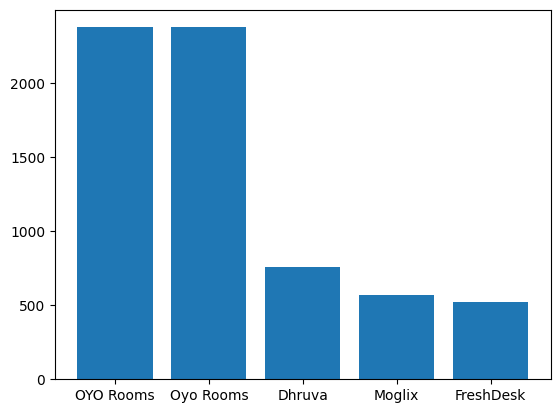

In [ ]:
plt.bar(x=big_df["Startup"],height=big_df["Amount"])

In [ ]:
df[df["Investors"].str.contains("Sequoia Capital India")].groupby("Vertical")["Amount"]\
    .sum().index

Index(['Consumer Internet', 'E-Commerce', 'E-commerce', 'Food & Beverage',
       'Healthcare', 'Logistics Tech', 'Technology', 'eCommerce'],
      dtype='object', name='Vertical')

In [ ]:
df[df["Investors"].str.contains("Sequoia Capital India")].groupby("Vertical")["Amount"]\
    .sum()

,Amount
Vertical,
Consumer Internet,6005.90
E-Commerce,570.00
E-commerce,174.41
Food & Beverage,59.85
Healthcare,57.00
Logistics Tech,139.46
Technology,788.50
eCommerce,114.00


In [ ]:
df[df["Investors"].str.contains("Sequoia Capital India")].groupby("Vertical")["Amount"]\
    .sum().values

array([6005.9 ,  570.  ,  174.41,   59.85,   57.  ,  139.46,  788.5 ,
        114.  ])

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
df['Year'] = df['Date'].dt.year

In [ ]:
df[df["Investors"].str.contains("Sequoia Capital India")].groupby("Year")["Amount"]\
    .sum().reset_index()

,Year,Amount
0,2016,902.50
1,2017,5831.10
2,2018,431.11
3,2019,570.00
4,2020,174.41


In [ ]:
round(df["Amount"].sum(),2)

np.float64(341475.59)

In [ ]:
round(df.groupby("Startup")["Amount"].max().sort_values(ascending=False).head(1).values[0])

37050

In [ ]:
df.groupby("Startup")["Amount"].max().sort_values(ascending=False).head(1).values

array([37050.])

In [ ]:
df["Startup"].nunique()

2305

In [ ]:
round(df.groupby("Startup")["Amount"].sum().mean())

148

In [ ]:
round(df.groupby("Startup")["Amount"].max().sort_values(ascending=False).head(1).values[0])

37050

In [ ]:
df['Month'] = df['Date'].dt.month
temp_df = df.groupby(["Year","Month"])["Startup"].count().reset_index()
temp_df

,Year,Month,Startup
0,2015,4,61
1,2015,5,55
2,2015,6,84
3,2015,7,95
4,2015,8,98
5,2015,9,87
6,2015,10,93
7,2015,11,90
8,2015,12,88
9,2016,1,104


In [ ]:
temp_df["x_axis"] = temp_df["Year"].astype(str) +"-"+ temp_df["Month"].astype(str)

In [ ]:
#temp_df[["Amount","x_axis"]]

In [ ]:
yoy = df[df["Investors"].str.contains(" 1Crowd")]\
        .groupby("Year")["Amount"].sum().reset_index()
yoy["Year"]

,Year
0,2016
1,2017


In [ ]:
df.columns

Index(['Date', 'Startup', 'Vertical', 'Subvertical', 'City', 'Investors',
       'Round', 'Amount', 'Year', 'Month'],
      dtype='object')

In [ ]:
df.groupby("Vertical")["Amount"].sum().sort_values(ascending=False).head(5)

,Amount
Vertical,
Consumer Internet,59305.21
eCommerce,47524.07
Transportation,37208.01
Technology,21179.89
ECommerce,17848.56


In [ ]:
df.groupby("Vertical")["Amount"].count().sort_values(ascending=False).head(5)

,Amount
Vertical,
Consumer Internet,927
Technology,476
eCommerce,186
Healthcare,69
ECommerce,61


In [ ]:
k = df.groupby("Round")["Amount"].count().sort_values(ascending=False).head(13)
k.drop(['Seed/ Angel Funding', 'Seed / Angel Funding','Seed/Angel Funding'])

,Amount
Round,
Seed Funding,1283
Private Equity,1265
Series A,24
Debt Funding,23
Series B,20
Series C,14
Series D,12
Angel / Seed Funding,8
Seed Round,7


In [ ]:
df.groupby("Round")["Amount"].count().sort_values(ascending=False).head(10).index.values

array(['Seed Funding', 'Private Equity', 'Seed/ Angel Funding',
       'Seed / Angel Funding', 'Series A', 'Debt Funding',
       'Seed/Angel Funding', 'Series B', 'Series C', 'Series D'],
      dtype=object)

In [ ]:
df.groupby("Round")["Amount"].count().sort_values(ascending=False).head(10).values

array([1283, 1265,   56,   41,   24,   23,   22,   20,   14,   12])

In [ ]:
df["City"] = df["City"].replace({"Bengaluru":"Bangalore","Gurugram":"Gurgaon"})
df.groupby("City")["Amount"].sum().sort_values(ascending=False).head(10)

,Amount
City,
Bangalore,175310.82
Mumbai,40842.60
Gurgaon,36730.28
New Delhi,28669.33
Noida,11997.23
Chennai,6828.29
Pune,6014.33
Menlo Park,4275.00
Hyderabad,3810.24


In [ ]:
df["Startup"] = df["Startup"].replace({"Flipkart.com":"Flipkart","Ola Cabs":"Ola","BYJU\\xe2\\x80\\x99s":"BYJU’S","Byju\\xe2\\x80\\x99s":"BYJU’S","BYJU\\'S":"BYJU’S","Rapido":"Rapido Bike Taxi","Olacabs":"Ola","Big Basket":"BigBasket"})
df.groupby("Startup")["Amount"].sum().sort_values(ascending=False).head(15)

,Amount
Startup,
Flipkart,45217.15
Rapido Bike Taxi,37057.14
Paytm,29915.03
Ola,19514.90
Udaan,8265.00
Snapdeal,6650.00
BigBasket,4864.00
GOQii,4275.00
Zomato,4132.50


In [ ]:
df.groupby("Startup")["Amount"].sum().sort_values(ascending=False).head(15)

,Amount
Startup,
Flipkart,45217.15
Rapido Bike Taxi,37057.14
Paytm,29915.03
Ola,19514.90
Udaan,8265.00
Snapdeal,6650.00
BigBasket,4864.00
GOQii,4275.00
Zomato,4132.50


In [ ]:
df.groupby("Investors")["Amount"].sum().sort_values(ascending=False).head(10).reset_index()

,Investors,Amount
0,Westbridge Capital,37050.00
1,Softbank,23750.00
2,SoftBank Group,13889.00
3,"Microsoft, eBay, Tencent Holdings",13300.00
4,Vijay Shekhar Sharma,9501.43
5,Steadview Capital and existing investors,6650.00
6,"Alibaba Group, Ant Financial",6460.00
7,"Altimeter Capital, DST Global",5557.50
8,SoftBank Vision Fund,5044.50
9,"Alibaba, Foxconn, Softbank",4750.00


In [ ]:
data = df.pivot_table(
        index='Vertical',
        columns='Round',
        values='Amount'
        )
data

Round,Angel,Angel / Seed Funding,Angel Funding,Angel Round,Bridge Round,Corporate Round,Debt,Debt Funding,Debt and Preference capital,Debt-Funding,...,Series H,Series J,Single Venture,Structured Debt,Term Loan,Venture,Venture - Series Unknown,Venture Round,pre-Series A,pre-series A
Vertical,,,,,,,,,,,,,,,,,,,,,
360-degree view creating platform,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3D Printer Manufacturer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
API Workflow platform,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accounting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
solar products and services marketplace,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
us ticketing and fleet management platform,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
usiness expense management,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830 entries, 0 to 2829
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2830 non-null   datetime64[ns]
 1   Startup      2830 non-null   object        
 2   Vertical     2830 non-null   object        
 3   Subvertical  2079 non-null   object        
 4   City         2830 non-null   object        
 5   Investors    2830 non-null   object        
 6   Round        2830 non-null   object        
 7   Amount       2830 non-null   float64       
 8   Year         2830 non-null   int32         
 9   Month        2830 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(2), object(6)
memory usage: 199.1+ KB


In [ ]:
df[df['Startup'] == "Flipkart"]

,Date,Startup,Vertical,Subvertical,City,Investors,Round,Amount,Year,Month
630,2017-08-11,Flipkart,eCommerce,Online Marketplace,Bangalore,Softbank,Private Equity,23750.00,2017,8
751,2017-06-26,Flipkart,eCommerce,Online marketplace,Bangalore,Naspers,Private Equity,674.50,2017,6
943,2017-03-21,Flipkart,eCommerce,ECommerce Marketplace,Bangalore,"Microsoft, eBay, Tencent Holdings",Private Equity,13300.00,2017,3
1009,2017-02-20,Flipkart,eCommerce,Online Marketplace,Bangalore,"Bennett, Coleman and Co. Ltd (BCCL)",Private Equity,367.65,2017,2
2612,2015-07-28,Flipkart,Online Marketplace,NaN,Bangalore,Steadview Capital and existing investors,Private Equity,6650.00,2015,7
2653,2015-06-04,Flipkart,eCommerce platform,NaN,Bangalore,Morgan Stanley,Private Equity,475.00,2015,6


In [ ]:
df[df['Startup'] == "Flipkart"]["Vertical"].values[0]

'eCommerce'

In [ ]:
df[df['Startup'] == "Flipkart"]["Subvertical"].values[0]

'Online Marketplace'

In [ ]:
df[df['Startup'] == "Rapido Bike Taxi"][["Round","Amount"]].set_index("Round").reset_index()

,Round,Amount
0,Series B,37050.00
1,Seed/Angel Funding,3.13
2,Seed Funding,4.01
3,Private Equity,0.00


In [ ]:
df[df['Startup'] == "Rapido Bike Taxi"][["Amount","Round"]].values[:,0]

array([37050.0, 3.13, 4.01, 0.0], dtype=object)

In [ ]:
df[df['Startup'] == "Flipkart"]["City"].values[0]

'Bangalore'